# 10 臂老虎机：高斯分布 + ε-贪心 + 平均价值估计

本 notebook 实现经典的 **k 臂老虎机（k-armed bandit）** 问题，k = 10：

1. **每个臂的奖励服从高斯（正态）分布**：臂 $a$ 的奖励 $R \sim \mathcal{N}(q_*(a),\, 1)$，
   其中真值 $q_*(a)$ 从 $\mathcal{N}(0,1)$ 中随机采样，且**在整次实验中固定不变**（平稳问题）。
2. **动作选择使用 ε-贪心（ε-greedy）**：以 $1-\varepsilon$ 的概率选择当前估计价值最大的臂（利用），
   以 $\varepsilon$ 的概率在 10 个臂中等概率随机选一个（探索）。
3. **价值估计使用平均法（sample average）**：
   $$Q_t(a) = \frac{\text{臂 } a \text{ 在第 } t \text{ 次被选中前获得的总奖励}}{\text{臂 } a \text{ 在第 } t \text{ 次被选中前的被选次数}}
   = \frac{\sum_{i=1}^{N_t(a)} R_i}{N_t(a)}$$
   若某臂从未被选过，规定 $Q_t(a) = 0$（本项目取初始值 0）。
   增量式更新公式：$Q_{n+1} = Q_n + \frac{1}{n}\big(R_n - Q_n\big)$。

**评价指标**：平均奖励（average reward）与最优动作选择比例（% optimal action）。


## 1. 导入依赖

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 让图表里的中文/负号正常显示（若系统无中文字体，可把字体换成 'Heiti TC' 或删掉这两行）
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "PingFang HK", "Heiti TC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

rng = np.random.default_rng(42)  # 固定随机种子，结果可复现
print("numpy:", np.__version__)

numpy: 2.3.5


## 2. 环境：k 臂高斯老虎机

- `q_star`：每个臂的真实期望奖励（固定）。
- `step(a)`：拉动手臂 `a`，返回 $R \sim \mathcal{N}(q_*(a), \sigma^2)$。
- `optimal_action`：真实期望最大的臂，用于统计最优动作比例。


In [2]:
class GaussianBandit:
    """k 臂老虎机，每个臂的奖励服从 N(q_star[a], std^2)，q_star 固定不变。"""

    def __init__(self, k=10, std=1.0, rng=None):
        self.k = k
        self.std = std
        self.rng = rng if rng is not None else np.random.default_rng()
        # 每个臂的真实期望价值：从 N(0, 1) 中随机采样，一次实验内保持不变
        self.q_star = self.rng.normal(loc=0.0, scale=1.0, size=k)
        self.optimal_action = int(np.argmax(self.q_star))

    def step(self, action):
        """执行动作 action，返回该臂的一次奖励采样。"""
        return float(self.rng.normal(self.q_star[action], self.std))

## 3. 智能体：ε-贪心 + 样本平均价值估计

`Q` 保存每个臂的价值估计，`N` 保存每个臂的被选次数。

- **平均法**（`use_incremental=False`）：每一步显式地用全部历史奖励求和再取平均
  $\;Q(a)=\frac{\sum R}{N(a)}$，最直观，等价于下面的增量式。
- **增量式平均**（`use_incremental=True`）：
  $Q_{n+1} = Q_n + \frac{1}{n}(R_n - Q_n)$，只需保存 $Q$ 和 $N$，内存 $O(k)$。

两种写法在数学上完全等价，本 notebook 默认使用增量式（快），并会验证二者结果一致。


In [3]:
class EpsilonGreedyAgent:
    """ε-贪心智能体，价值估计为历史奖励的平均值（初始值 0）。"""

    def __init__(self, k=10, epsilon=0.1, use_incremental=True, rng=None):
        self.k = k
        self.epsilon = epsilon
        self.use_incremental = use_incremental
        self.rng = rng if rng is not None else np.random.default_rng()
        self.Q = np.zeros(k)          # 价值估计，初始值 0
        self.N = np.zeros(k, dtype=int)  # 每个臂被选中的次数
        self.rewards_sum = np.zeros(k)   # 仅用于“非增量式”版本的求和

    # ---------- 动作选择：ε-贪心 ----------
    def select_action(self):
        if self.rng.random() < self.epsilon:
            # 探索：等概率随机选一个臂
            return int(self.rng.integers(self.k))
        # 利用：选当前估计价值最大的臂（并列时等概率随机，避免固定偏向小编号臂）
        best = np.flatnonzero(self.Q == self.Q.max())
        return int(self.rng.choice(best))

    # ---------- 价值估计：样本平均 ----------
    def update(self, action, reward):
        self.N[action] += 1
        if self.use_incremental:
            # 增量式平均：Q <- Q + (1/n)(R - Q)
            step_size = 1.0 / self.N[action]
            self.Q[action] += step_size * (reward - self.Q[action])
        else:
            # 直白的平均：重新对全部历史奖励求均值
            self.rewards_sum[action] += reward
            self.Q[action] = self.rewards_sum[action] / self.N[action]

## 4. 单次实验 + 多次独立重复实验

老虎机和智能体都是随机的，单次实验噪声很大，通常要在 **2000 次独立重复实验** 上取平均，
才能看出 ε-贪心随时间的收敛趋势（这也是 Sutton & Barto 书中的标准做法）。


In [4]:
def run_experiment(k=10, steps=1000, epsilon=0.1, bandit_std=1.0, runs=2000,
                   use_incremental=True, seed=0):
    """重复 runs 次独立实验，返回平均奖励与最优动作比例两条曲线。"""
    rewards = np.zeros((runs, steps))
    optimal = np.zeros((runs, steps))
    for run in range(runs):
        run_rng = np.random.default_rng(seed + run)
        bandit = GaussianBandit(k=k, std=bandit_std, rng=run_rng)
        agent = EpsilonGreedyAgent(k=k, epsilon=epsilon,
                                   use_incremental=use_incremental, rng=run_rng)
        for t in range(steps):
            a = agent.select_action()
            r = bandit.step(a)
            agent.update(a, r)
            rewards[run, t] = r
            optimal[run, t] = (a == bandit.optimal_action)
    return rewards, optimal


def moving_average(x, window=20):
    """滑动平均，仅用于把单次实验的噪声曲线画得好看一点。"""
    if window <= 1:
        return x
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")

In [5]:
# 单次实验（ε = 0.1），看智能体是怎么学到最优臂的
bandit = GaussianBandit(k=10, rng=np.random.default_rng(1))
agent = EpsilonGreedyAgent(k=10, epsilon=0.1, rng=np.random.default_rng(2))

single_rewards = np.zeros(1000)
single_optimal = np.zeros(1000)
for t in range(1000):
    a = agent.select_action()
    r = bandit.step(a)
    agent.update(a, r)
    single_rewards[t] = r
    single_optimal[t] = (a == bandit.optimal_action)

print("真实期望 q*(a):", np.round(bandit.q_star, 2))
print("最优臂:", bandit.optimal_action)
print("学到的估计 Q(a):", np.round(agent.Q, 2))
print("各臂被选次数 N(a):", agent.N)
print(f"最优臂的估计排名: {int(np.argmax(agent.Q)) == bandit.optimal_action}")
print(f"最后 100 步最优动作比例: {single_optimal[-100:].mean():.1%}")

真实期望 q*(a): [ 0.35  0.82  0.33 -1.3   0.91  0.45 -0.54  0.58  0.36  0.29]
最优臂: 4
学到的估计 Q(a): [-0.05  0.72  0.7  -1.56  0.87  0.61 -0.4   0.19  0.33  0.07]
各臂被选次数 N(a): [  8 290  12   5 642   8   8  12   8   7]
最优臂的估计排名: True
最后 100 步最优动作比例: 94.0%


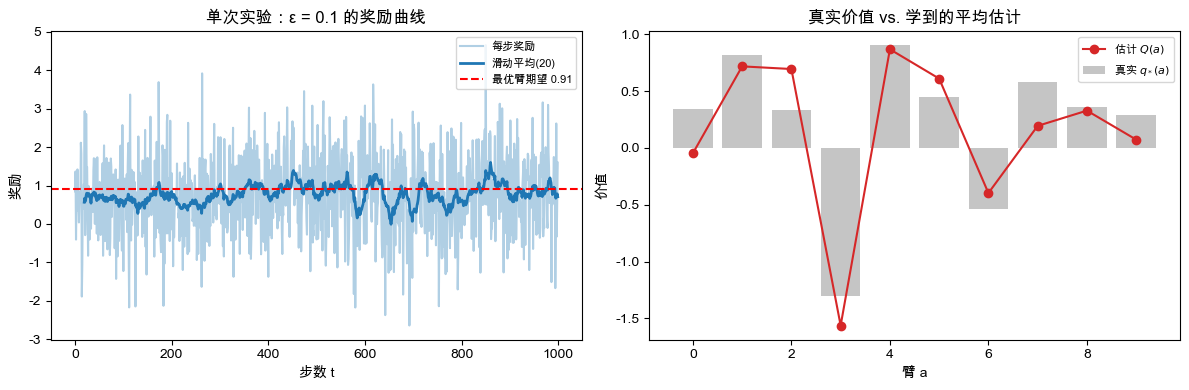

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(single_rewards, color="tab:blue", alpha=0.35, label="每步奖励")
axes[0].plot(np.arange(19, 1000), moving_average(single_rewards, 20),
             color="tab:blue", lw=2, label="滑动平均(20)")
axes[0].axhline(bandit.q_star.max(), color="red", ls="--", lw=1.5,
                label=f"最优臂期望 {bandit.q_star.max():.2f}")
axes[0].set_xlabel("步数 t")
axes[0].set_ylabel("奖励")
axes[0].set_title("单次实验：ε = 0.1 的奖励曲线")
axes[0].legend(fontsize=8)

axes[1].bar(range(10), bandit.q_star, alpha=0.45, color="gray", label="真实 $q_*(a)$")
axes[1].plot(range(10), agent.Q, "o-", color="tab:red", label="估计 $Q(a)$")
axes[1].set_xlabel("臂 a")
axes[1].set_ylabel("价值")
axes[1].set_title("真实价值 vs. 学到的平均估计")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 验证：增量式平均 == 直接求平均

下面用同一个随机种子分别跑"增量式"和"直接求和求平均"两种实现，比较最终的价值估计，
确认两者数值一致（差异只来自浮点误差）。


In [7]:
runs_inc, opt_inc = run_experiment(epsilon=0.1, runs=30, seed=100, use_incremental=True)
runs_avg, opt_avg = run_experiment(epsilon=0.1, runs=30, seed=100, use_incremental=False)

print("增量式 与 直接平均 的平均奖励最大差异:", np.abs(runs_inc - runs_avg).max())
print("两者是否在浮点误差内一致:", np.allclose(runs_inc, runs_avg, atol=1e-9))

增量式 与 直接平均 的平均奖励最大差异: 0.0
两者是否在浮点误差内一致: True


## 5. 对比不同 $\varepsilon$

固定其它条件，只改变探索率 $\varepsilon \in \{0,\ 0.01,\ 0.1\}$，各做 2000 次独立重复实验：

- $\varepsilon = 0$（纯贪心）：容易**过早锁定**次优臂，长期平均奖励明显更低；
- $\varepsilon$ 太小：前期探索不足，收敛慢；
- $\varepsilon$ 太大：一直在随机乱试，稳定后仍有约 $\varepsilon$ 的步数浪费在非最优臂上，长期奖励被拉低。

因此 $\varepsilon$ 需要在"探索"与"利用"之间权衡。


In [8]:
epsilons = [0.0, 0.01, 0.1]
STEPS, RUNS = 1000, 2000
colors = ["tab:green", "tab:orange", "tab:blue"]

results = {}
for eps, c in zip(epsilons, colors):
    r, o = run_experiment(k=10, steps=STEPS, epsilon=eps, runs=RUNS, seed=1000)
    results[eps] = (r.mean(axis=0), o.mean(axis=0))
    print(f"ε = {eps:<5} 完成 | 全程平均奖励 = {r.mean():.3f} | "
          f"最后100步最优动作比例 = {o[:, -100:].mean():.1%}")

ε = 0.0   完成 | 全程平均奖励 = 1.031 | 最后100步最优动作比例 = 36.4%


ε = 0.01  完成 | 全程平均奖励 = 1.211 | 最后100步最优动作比例 = 61.6%


ε = 0.1   完成 | 全程平均奖励 = 1.301 | 最后100步最优动作比例 = 79.6%


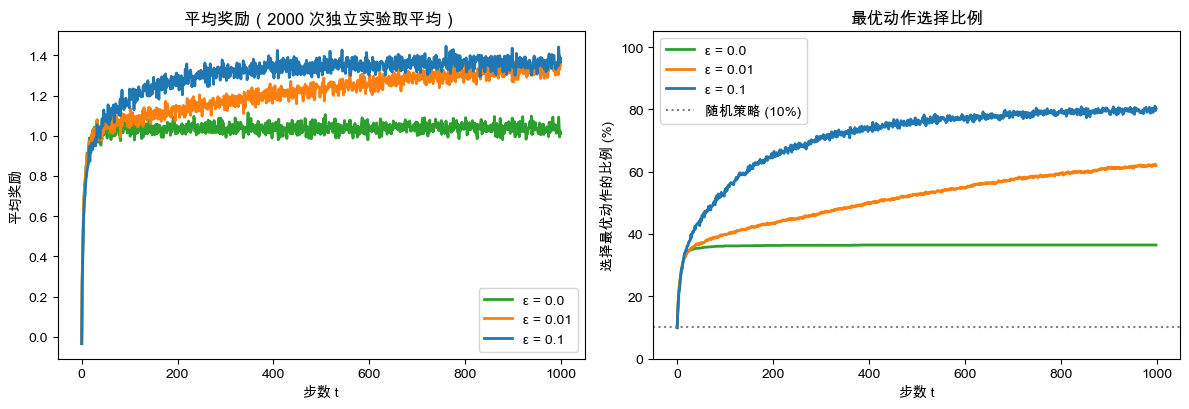

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for eps, c in zip(epsilons, colors):
    avg_r, avg_o = results[eps]
    axes[0].plot(avg_r, color=c, lw=2, label=f"ε = {eps}")
    axes[1].plot(avg_o * 100, color=c, lw=2, label=f"ε = {eps}")

axes[0].set_xlabel("步数 t")
axes[0].set_ylabel("平均奖励")
axes[0].set_title(f"平均奖励（{RUNS} 次独立实验取平均）")
axes[0].legend()

axes[1].axhline(10, color="gray", ls=":", label="随机策略 (10%)")
axes[1].set_ylim(0, 105)
axes[1].set_xlabel("步数 t")
axes[1].set_ylabel("选择最优动作的比例 (%)")
axes[1].set_title("最优动作选择比例")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. 可选：初始值 / 非平稳问题的简单讨论

- **乐观初始值**：把 $Q_0$ 设成正数（如 5），纯贪心（$\varepsilon=0$）也会被迫先探索每个臂，
  之后自然收敛，是"用初始值鼓励探索"的经典技巧。
- **非平稳问题**：如果 $q_*(a)$ 随时间漂移，样本平均会越来越"迟钝"，
  此时应改用指数近似的加权平均 $Q_{n+1}=Q_n+\alpha(R_n-Q_n)$。

下面把初始值设成 5 做个小实验，观察纯贪心的表现是否改善。


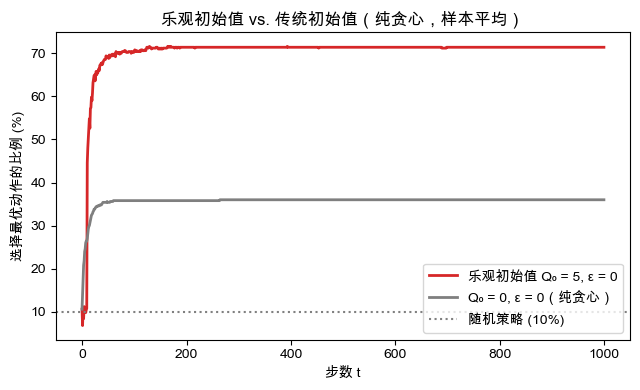

In [10]:
def run_optimistic(k=10, steps=1000, runs=500, q_init=5.0, alpha=None, seed=0):
    """乐观初始值 + ε=0（纯贪心）；alpha 为 None 时用样本平均。"""
    rewards = np.zeros((runs, steps))
    optimal = np.zeros((runs, steps))
    for run in range(runs):
        run_rng = np.random.default_rng(seed + run)
        bandit = GaussianBandit(k=k, rng=run_rng)
        Q = np.full(k, q_init)
        N = np.zeros(k, dtype=int)
        for t in range(steps):
            best = np.flatnonzero(Q == Q.max())
            a = int(run_rng.choice(best))
            r = bandit.step(a)
            N[a] += 1
            step_size = alpha if alpha is not None else 1.0 / N[a]
            Q[a] += step_size * (r - Q[a])
            rewards[run, t] = r
            optimal[run, t] = (a == bandit.optimal_action)
    return rewards.mean(axis=0), optimal.mean(axis=0)


opt_r, opt_o = run_optimistic(q_init=5.0, seed=2000)
bad_r, bad_o = run_optimistic(q_init=0.0, seed=2000)

plt.figure(figsize=(6.5, 4))
plt.plot(opt_o * 100, color="tab:red", lw=2, label="乐观初始值 Q₀ = 5, ε = 0")
plt.plot(bad_o * 100, color="tab:gray", lw=2, label="Q₀ = 0, ε = 0（纯贪心）")
plt.axhline(10, color="gray", ls=":", label="随机策略 (10%)")
plt.xlabel("步数 t")
plt.ylabel("选择最优动作的比例 (%)")
plt.title("乐观初始值 vs. 传统初始值（纯贪心，样本平均）")
plt.legend()
plt.tight_layout()
plt.show()

## 7. 小结

| 要点 | 本 notebook 的做法 |
| --- | --- |
| 环境 | 10 个臂，$R \sim \mathcal{N}(q_*(a), 1)$，$q_*(a) \sim \mathcal{N}(0,1)$ 且固定 |
| 动作选择 | ε-贪心：$1-\varepsilon$ 利用 argmax Q，$\varepsilon$ 等概率随机探索 |
| 价值估计 | **样本平均**（增量式 $Q \leftarrow Q + \frac{1}{N}(R-Q)$，与非增量式等价） |
| 结论 | 纯贪心会过早锁定次优臂；$arepsilon \approx 0.1$ 在前期探索与后期稳定之间较均衡 |

可继续尝试的改动：改变奖励噪声 `bandit_std`、臂数 `k`、步数 `steps`；
或把样本平均换成固定步长 $\alpha$ 以应对非平稳环境。
